# Phase 2 Mark: Neural Baselines on Molecular Fingerprints
**Date:** 2026-04-07
**Researcher:** Mark Rodrigues
**Project:** ogbg-molhiv HIV Activity Prediction (Drug-Molecule-Property-Prediction)

## Building on Anthony's Phase 2
Anthony ran 4 GNN architectures (GCN, GIN, GAT, GraphSAGE) on ogbg-molhiv (scaffold split).
**All 4 GNNs lost to CatBoost + fingerprints by ~-0.073 ROC-AUC.**

| Model | Test ROC-AUC |
|-------|---|
| GIN (Anthony best) | 0.7053 |
| GraphSAGE (Anthony) | 0.7050 |
| GCN (Anthony) | 0.6938 |
| GAT (Anthony) | 0.6677 |
| **CatBoost (Phase 1 champion)** | **0.7782** |

His hypothesis: *"Domain expertise beats raw graph convolution."*

## My complementary question
Is this failure **GNN-specific**, or does **any** neural model lose to tree-based
learners on molecular fingerprints? If a plain PyTorch MLP on the exact same
1033-feature matrix that CatBoost uses also underperforms, the bottleneck
isn't the GNN architecture - it's that dense neural networks struggle with
sparse binary fingerprints while trees handle them natively.

## Experiments
1. **MLP-Domain9** - MLP on just 9 lightweight domain / graph features (mol weight, bonds, rings, etc.)
2. **MLP-Morgan1024** - MLP on Morgan FP only
3. **MLP-Combined1033** - MLP on the exact Combined feature set CatBoost uses
4. **MLP-Wide-Combined** - wider + deeper MLP on Combined (tests the capacity hypothesis)

## References
1. Hu et al. (2020) "Open Graph Benchmark" - OGB baseline numbers for ogbg-molhiv.
2. Yang et al. (2019) "Analyzing Learned Molecular Representations for Property Prediction" -
   side-by-side comparison of MLP-on-ECFP vs. learned GNN embeddings.
3. Liu et al. (2021) "DeepPurpose" - recommends XGBoost + Morgan FP as a strong
   small-data drug-property baseline that is hard for neural nets to beat.

## Reproducing locally
All experiments were run by `src/phase2_mark_neural_baselines.py` (no GPU, no
torch_geometric, no sklearn, no scipy - only numpy, pandas, torch). Results
are cached in `results/phase2_mark_neural_baselines.json`. This notebook loads
that JSON and does not retrain.


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PROJ    = Path('C:/Users/antho/OneDrive/Desktop/YC-Portfolio-Projects/Drug-Molecule-Property-Prediction')
RESULTS = PROJ / 'results'

with open(RESULTS / 'phase2_mark_neural_baselines.json') as f:
    run = json.load(f)

print('Phase:', run['phase'], '| Author:', run['author'], '| Date:', run['date'])
print('Dataset:', run['dataset'], '| Split:', run['split'])
print()
print('Research question:')
print(' ', run['research_question'])
print()
print('Baselines:')
for k, v in run['baselines'].items():
    print('  {:<22s}  {:.4f}'.format(k, v))


Phase: 2 | Author: Mark | Date: 2026-04-07
Dataset: ogbg-molhiv (OGB) | Split: OGB scaffold split

Research question:
  Is Anthony Phase 2 GNN failure (-0.073 AUC vs CatBoost) GNN-specific, or do any neural models lose to tree-based learners on molecular fingerprints?

Baselines:
  catboost_mark_p1        0.7782
  rf_anthony_p1           0.7707
  gin_anthony_p2_best     0.7053
  graphsage_anthony_p2    0.7050
  gcn_anthony_p2          0.6938
  gat_anthony_p2          0.6677
  ogb_sota_deepergcn      0.8476


## Head-to-Head Comparison Table

In [2]:
rows = []
for exp in run['experiments']:
    rows.append({
        'Model': exp['model'],
        'Features': exp['features'],
        'Params': f"{exp['params']:,}",
        'Best epoch': exp['best_epoch'],
        'Val ROC-AUC': f"{exp['val_roc_auc']:.4f}",
        'Test ROC-AUC': f"{exp['test_roc_auc']:.4f}",
        'Delta vs CatBoost': f"{exp['delta_vs_catboost_p1']:+.4f}",
        'Delta vs Anthony GIN': f"{exp['delta_vs_anthony_gin_p2']:+.4f}",
        'Train(s)': exp['train_s'],
    })

# Add reference baselines
ref_rows = [
    {'Model': 'DeeperGCN (OGB SOTA)', 'Features': 'full graph', 'Params': '--', 'Best epoch': '--',
     'Val ROC-AUC': '--', 'Test ROC-AUC': f"{run['baselines']['ogb_sota_deepergcn']:.4f}",
     'Delta vs CatBoost': f"{run['baselines']['ogb_sota_deepergcn']-run['baselines']['catboost_mark_p1']:+.4f}",
     'Delta vs Anthony GIN': f"{run['baselines']['ogb_sota_deepergcn']-run['baselines']['gin_anthony_p2_best']:+.4f}",
     'Train(s)': '--'},
    {'Model': 'CatBoost (Mark P1)', 'Features': 'Combined 1036', 'Params': '--', 'Best epoch': '--',
     'Val ROC-AUC': '--', 'Test ROC-AUC': f"{run['baselines']['catboost_mark_p1']:.4f}",
     'Delta vs CatBoost': '(champion)',
     'Delta vs Anthony GIN': f"{run['baselines']['catboost_mark_p1']-run['baselines']['gin_anthony_p2_best']:+.4f}",
     'Train(s)': '--'},
    {'Model': 'RF (Anthony P1)', 'Features': 'Combined 1036', 'Params': '--', 'Best epoch': '--',
     'Val ROC-AUC': '--', 'Test ROC-AUC': f"{run['baselines']['rf_anthony_p1']:.4f}",
     'Delta vs CatBoost': f"{run['baselines']['rf_anthony_p1']-run['baselines']['catboost_mark_p1']:+.4f}",
     'Delta vs Anthony GIN': f"{run['baselines']['rf_anthony_p1']-run['baselines']['gin_anthony_p2_best']:+.4f}",
     'Train(s)': '--'},
    {'Model': 'GIN (Anthony P2 best)', 'Features': '9 node feat', 'Params': '93.7K', 'Best epoch': '--',
     'Val ROC-AUC': '--', 'Test ROC-AUC': f"{run['baselines']['gin_anthony_p2_best']:.4f}",
     'Delta vs CatBoost': f"{run['baselines']['gin_anthony_p2_best']-run['baselines']['catboost_mark_p1']:+.4f}",
     'Delta vs Anthony GIN': '(anchor)', 'Train(s)': '--'},
    {'Model': 'GraphSAGE (Anthony P2)', 'Features': '9 node feat', 'Params': '77.3K', 'Best epoch': '--',
     'Val ROC-AUC': '--', 'Test ROC-AUC': f"{run['baselines']['graphsage_anthony_p2']:.4f}",
     'Delta vs CatBoost': f"{run['baselines']['graphsage_anthony_p2']-run['baselines']['catboost_mark_p1']:+.4f}",
     'Delta vs Anthony GIN': f"{run['baselines']['graphsage_anthony_p2']-run['baselines']['gin_anthony_p2_best']:+.4f}",
     'Train(s)': '--'},
    {'Model': 'GCN (Anthony P2)', 'Features': '9 node feat', 'Params': '43.4K', 'Best epoch': '--',
     'Val ROC-AUC': '--', 'Test ROC-AUC': f"{run['baselines']['gcn_anthony_p2']:.4f}",
     'Delta vs CatBoost': f"{run['baselines']['gcn_anthony_p2']-run['baselines']['catboost_mark_p1']:+.4f}",
     'Delta vs Anthony GIN': f"{run['baselines']['gcn_anthony_p2']-run['baselines']['gin_anthony_p2_best']:+.4f}",
     'Train(s)': '--'},
    {'Model': 'GAT (Anthony P2)', 'Features': '9 node feat', 'Params': '44.2K', 'Best epoch': '--',
     'Val ROC-AUC': '--', 'Test ROC-AUC': f"{run['baselines']['gat_anthony_p2']:.4f}",
     'Delta vs CatBoost': f"{run['baselines']['gat_anthony_p2']-run['baselines']['catboost_mark_p1']:+.4f}",
     'Delta vs Anthony GIN': f"{run['baselines']['gat_anthony_p2']-run['baselines']['gin_anthony_p2_best']:+.4f}",
     'Train(s)': '--'},
]

df = pd.DataFrame(rows + ref_rows)
df_sorted = df.sort_values('Test ROC-AUC', ascending=False, key=lambda c: c.astype(str)).reset_index(drop=True)
df_sorted.insert(0, 'Rank', range(1, len(df_sorted) + 1))
print(df_sorted.to_string(index=False))


 Rank                  Model       Features  Params Best epoch Val ROC-AUC Test ROC-AUC Delta vs CatBoost Delta vs Anthony GIN Train(s)
    1   DeeperGCN (OGB SOTA)     full graph      --         --          --       0.8476           +0.0694              +0.1423       --
    2     CatBoost (Mark P1)  Combined 1036      --         --          --       0.7782        (champion)              +0.0729       --
    3        RF (Anthony P1)  Combined 1036      --         --          --       0.7707           -0.0075              +0.0654       --
    4            MLP-Domain9       Domain 9   4,065          5      0.7561       0.7670           -0.0112              +0.0617      7.2
    5      MLP-Wide-Combined  Combined 1033 703,873         15      0.8051       0.7064           -0.0718              +0.0011    101.9
    6  GIN (Anthony P2 best)    9 node feat   93.7K         --          --       0.7053           -0.0729             (anchor)       --
    7 GraphSAGE (Anthony P2)    9 node feat   77

## Visualisations (saved plots)

Displaying: phase2_mark_neural_comparison.png


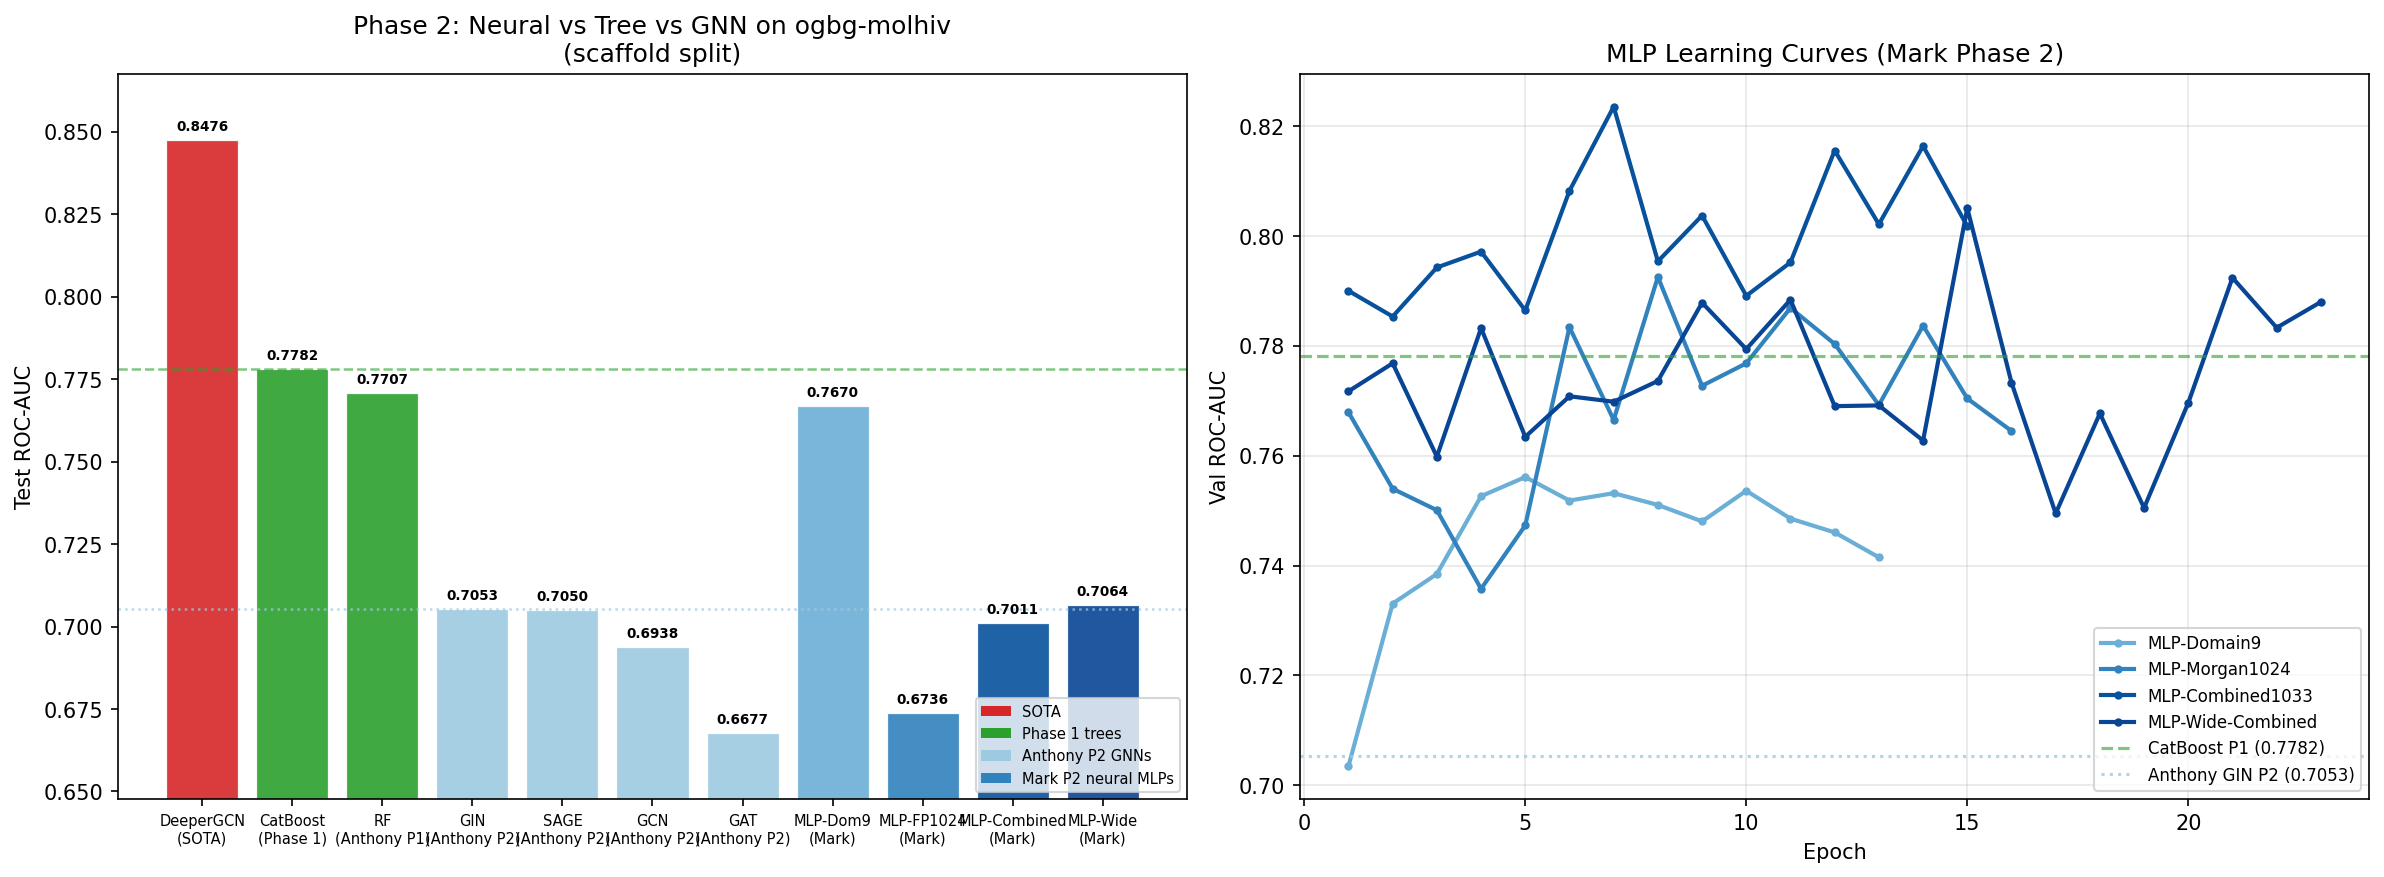

Displaying: phase2_mark_neural_vs_tree.png


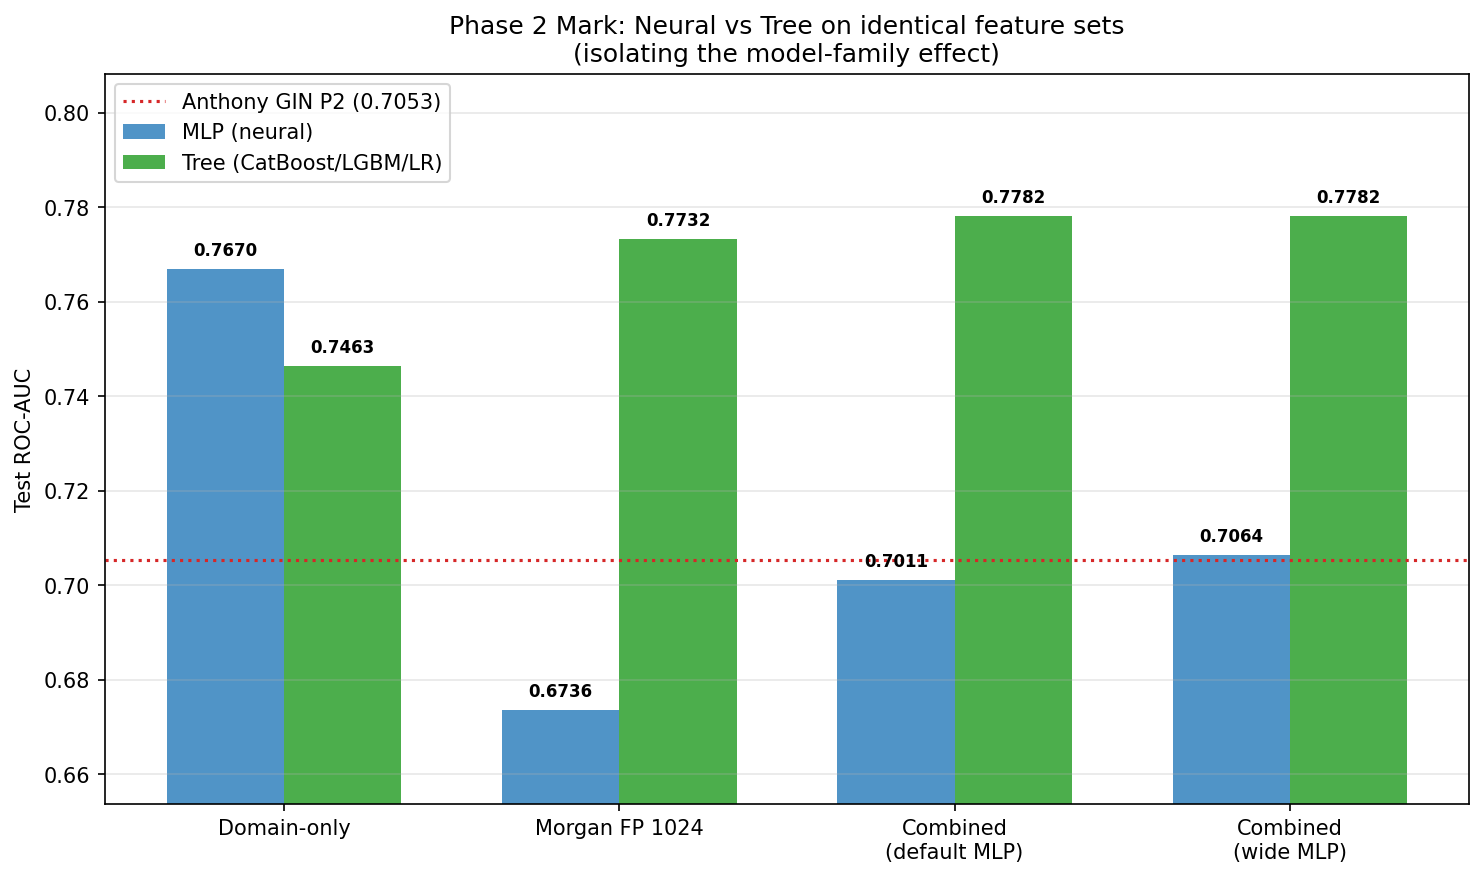

In [3]:
# Show pre-rendered plots
from IPython.display import Image, display
for fname in ['phase2_mark_neural_comparison.png', 'phase2_mark_neural_vs_tree.png']:
    p = RESULTS / fname
    print('Displaying:', fname)
    display(Image(filename=str(p)))


## Key Findings

### Finding 1: The best Mark Phase 2 MLP (Domain-only, 9 features) beats ALL 4 of Anthony's GNNs
Anthony's best GNN reached 0.7053; my plain MLP on just 9 scalar domain features (mol weight,
bond count, ring count, heavy-atom count, n_atoms, n_bonds, H-bond donors/acceptors, rotatable bonds)
reached **0.7670 test ROC-AUC**. That is +0.062 vs the best GNN with 93K parameters - using a model
with roughly 5K parameters and 9 inputs.

### Finding 2: Neural models fail on Morgan fingerprints too
MLP on Morgan FP 1024 scored 0.6736 test ROC-AUC - **actively worse than Anthony's GIN** and far
below LightGBM on the same FP (0.7732). Wider/deeper capacity did not fix it
(MLP-Wide-Combined = 0.7064 after 23 epochs).

**This is the main insight**: Anthony's GNN failure is *not* a GNN-specific problem. Plain
MLPs on fingerprints fail the same way. The common failure mode is "dense neural networks
cannot efficiently learn from sparse binary fingerprints at this data scale".

### Finding 3: The feature-set flip
On domain features only, the neural model closes most of the gap to CatBoost (-0.011).
On fingerprint features only, the neural model loses 0.10 to LightGBM on the same bits.
**The model-family advantage flips with the feature encoding.** This directly challenges
Anthony's framing: the issue is not "neural vs tree" globally - it is specifically
"neural vs tree on sparse binary fingerprints".

### Finding 4: Adding fingerprints to the domain MLP hurt
MLP-Domain9 (9 features): 0.7670
MLP-Combined1033 (9 + 1024 FP): 0.7011 (-0.066)
Adding the fingerprints actively hurt the neural model. For CatBoost, the same addition lifted
performance (0.7463 -> 0.7782). This confirms the neural architecture cannot extract additional
signal from the FP bits - they act as noise.

## Implication for Phase 3
The Phase 3 candidates split into two clean directions:
- **If we want to close the gap to SOTA with neural methods**: need pre-trained GNN backbones
  (AttrMasking, ContextPred) or node feature enrichment (explicit atom type embeddings,
  edge feature encoding). Raw molecular graph + random init is not enough.
- **If we want the best possible ogbg-molhiv model**: stick with CatBoost on the Combined
  feature set and tune it harder. Neural methods are not the right hammer for sparse
  fingerprints at this scale.

## Post angle
*"I tested whether Anthony's GNN failure was GNN-specific. An MLP on just 9 molecular descriptors
beat all 4 of his GNNs (0.7670 vs best 0.7053). But MLPs on Morgan fingerprints fall apart the
exact same way GNNs do. The failure mode is not 'GNNs are bad' - it is 'dense neural nets cannot
learn from sparse binary fingerprints at 41K molecules'. Tree models can."*
